# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
import time

import tltorch
from Utils.Reshape import reshape

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Synthetic Data

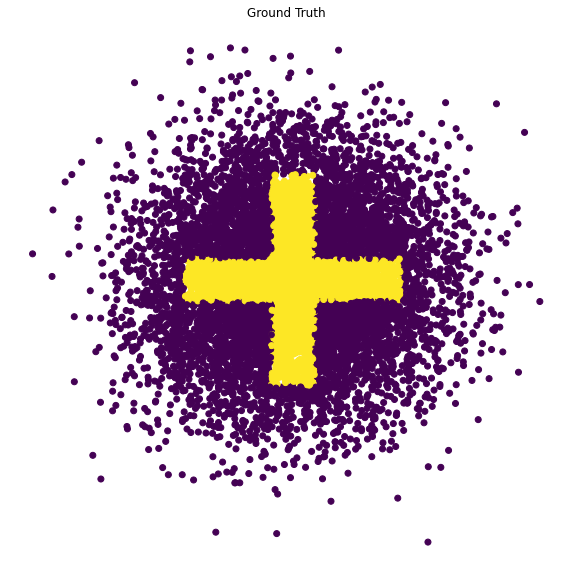

device is : cuda
shape of data is :torch.Size([10000, 256, 256])


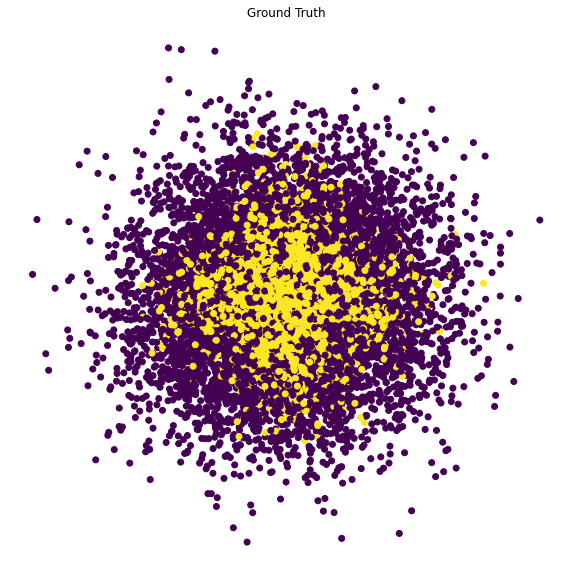

In [16]:
n_samples = 10000
np.random.seed(1234)
data = np.random.normal(loc=0, scale=np.sqrt(5), size=(n_samples, 256*256))
noise = np.random.normal(loc=0, scale=np.sqrt(1), size=(n_samples, 256*256))
r = 3.5
l = 0.7
def custom_shape_boundary(x, y):
    return ((np.abs(x) < l) | (np.abs(y) < l)) & (((x>=-r) & (x<=0)) | ((x<=r) & (x>=0))) & (((y>=-r) & (y<=0)) | ((y<=r) & (y>=0)))

labels = custom_shape_boundary(data[:,0], data[:,1]).astype(int)

fig = plt.figure(figsize=(10,10))
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.title('Ground Truth')
plt.axis('off')
plt.show()


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is : {device}')
data = data+noise
data = torch.from_numpy(data.reshape(-1,256,256))
data = data.to(device)
data = data.float()
labels = torch.from_numpy(labels)
labels = labels.to(device)
print(f'shape of data is :{data.shape}')


data = data.reshape(-1,256*256)
data = data.cpu().numpy()
labels = labels.cpu().numpy()
fig = plt.figure(figsize=(10,10))
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.title('Ground Truth')
plt.axis('off')
plt.show()

# Basic Linear Model

Epoch [1/5], Loss: 1.070151686668396, train - accuracy: 0.504
Epoch [2/5], Loss: 0.2121855914592743, train - accuracy: 0.9422
Epoch [3/5], Loss: 0.04935694858431816, train - accuracy: 0.9993
Epoch [4/5], Loss: 0.01672731153666973, train - accuracy: 1.0
Epoch [5/5], Loss: 0.006861349567770958, train - accuracy: 1.0
Done Training


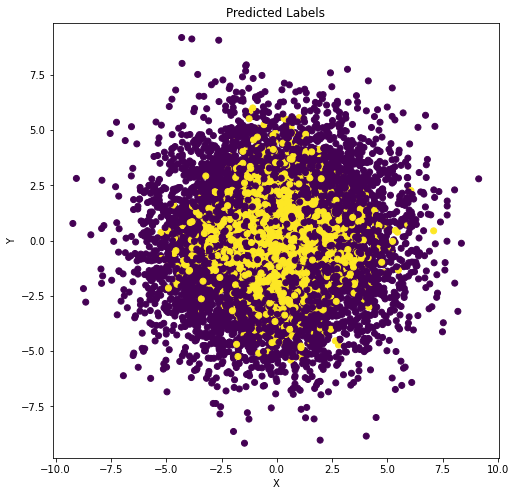

In [114]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= 256*256, out_features=2)
    def forward(self, x):
        x = x.reshape(-1,256*256)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 5 epochs
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    _, predict = torch.max(outputs, 1)
    accuracy = (predict == labels).sum().item() / len(data)
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}, train - accuracy: {accuracy}')

print(f'Done Training')
model.eval()
outputs = model(data)
_, predict = torch.max(outputs, 1)

    
# Plot the results
fig, ax = plt.subplots(figsize=(8, 8))
data = data.reshape(-1,256*256)
data = data.cpu().numpy()
predict = predict.cpu().numpy()
ax.scatter(data[:, 0], data[:, 1], c=predict)
ax.set_title('Predicted Labels')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
plt.show()

data = torch.from_numpy(data.reshape(-1,256,256))
data = data.to(device)
data = data.float()

# Basic TRL Model

Epoch [1/5], Loss: 372.6150207519531, train - accuracy: 0.4958
Epoch [2/5], Loss: 349.9047546386719, train - accuracy: 0.5071
Epoch [3/5], Loss: 328.1787109375, train - accuracy: 0.5201
Epoch [4/5], Loss: 307.4977111816406, train - accuracy: 0.5376
Epoch [5/5], Loss: 287.7344970703125, train - accuracy: 0.5508
Done Training


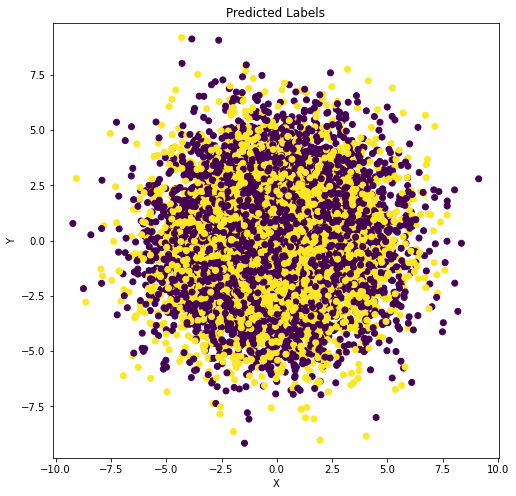

In [129]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(256,256), rank=(256,256,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 5 epochs
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    _, predict = torch.max(outputs, 1)
    accuracy = (predict == labels).sum().item() / len(data)
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}, train - accuracy: {accuracy}')

print(f'Done Training')
model.eval()
outputs = model(data)
_, predict = torch.max(outputs, 1)

    
# Plot the results
fig, ax = plt.subplots(figsize=(8, 8))
data = data.reshape(-1,256*256)
data = data.cpu().numpy()
predict = predict.cpu().numpy()
ax.scatter(data[:, 0], data[:, 1], c=predict)
ax.set_title('Predicted Labels')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
plt.show()

data = torch.from_numpy(data.reshape(-1,256,256))
data = data.to(device)
data = data.float()

# Basic Attached Model

In [13]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,2,2,1,128,128), rank=(1,2,2,1,128,128,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

model(data).shape

torch.Size([10000, 2])

Epoch [1/5], Loss: 1.577973484992981, train - accuracy: 0.5116
Epoch [2/5], Loss: 1.263459324836731, train - accuracy: 0.5137
Epoch [3/5], Loss: 0.9958479404449463, train - accuracy: 0.517
Epoch [4/5], Loss: 0.7946407198905945, train - accuracy: 0.522
Epoch [5/5], Loss: 0.6926200985908508, train - accuracy: 0.5349
Done Training


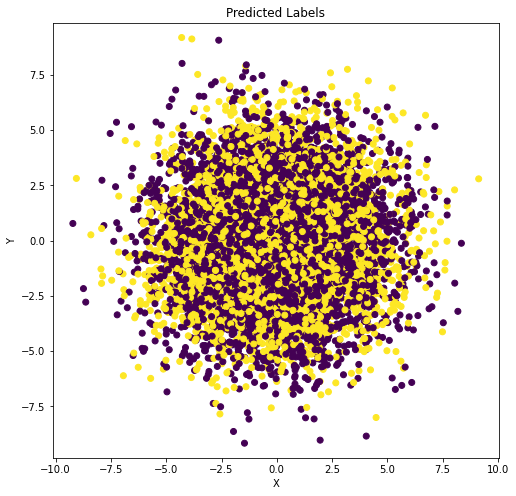

In [14]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,2,2,1,128,128), rank=(1,2,2,1,128,128,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    _, predict = torch.max(outputs, 1)
    accuracy = (predict == labels).sum().item() / len(data)
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}, train - accuracy: {accuracy}')

print(f'Done Training')
model.eval()
outputs = model(data)
_, predict = torch.max(outputs, 1)

    
# Plot the results
fig, ax = plt.subplots(figsize=(8, 8))
data = data.reshape(-1,256*256)
data = data.cpu().numpy()
predict = predict.cpu().numpy()
ax.scatter(data[:, 0], data[:, 1], c=predict)
ax.set_title('Predicted Labels')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
plt.show()

data = torch.from_numpy(data.reshape(-1,256,256))
data = data.to(device)
data = data.float()

# Basic Compressed Model